# Social Media Computing Project

## Data Preparation

### Connecting to Google Drive

In [ ]:
# Import the necessary libraries for today's session
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import nltk

nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Mount Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Loading Dataset

In [ ]:
df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/chatgpt_sentiment.csv')
df.head()

,Text,negative,neutral,positive,predicted_label,date,likes,location,followers,following,retweets,replies
0,If I were a journalist or reporter writing cli...,0.947877,0.040978,0.011144,negative,2023-02-10 23:59:49+00:00,1,Fukuoka 福岡 | Japan 日本,2012,388,0,0
1,Imagine if the mid season twist was that theyr...,0.031874,0.156266,0.811859,positive,2023-02-10 23:59:35+00:00,8,"Manhattan, NY",19855,5722,1,2
2,I see the difference between leader and employ...,0.158342,0.312784,0.528873,positive,2023-02-10 23:59:18+00:00,4,NaN,23,577,0,1
3,Which means your job is at risk Bill Gates say...,0.023860,0.931395,0.044745,neutral,2023-02-10 23:59:16+00:00,0,NaN,108,224,0,0
4,What have you been using Chatgpt for?,0.005627,0.968457,0.025916,neutral,2023-02-10 23:59:16+00:00,1,"Chicago, IL",11155,478,0,1


### Understanding Data

In [ ]:
# Check the total number of rows and columns
print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns.\n")

# Check the data types and look for missing values
print("Dataset Information:")
df.info()

Dataset Shape: 975450 rows and 12 columns.

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 975450 entries, 0 to 975449
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Text             975027 non-null  object 
 1   negative         975450 non-null  float64
 2   neutral          975450 non-null  float64
 3   positive         975450 non-null  float64
 4   predicted_label  975450 non-null  object 
 5   date             975450 non-null  object 
 6   likes            975450 non-null  int64  
 7   location         705265 non-null  object 
 8   followers        975450 non-null  int64  
 9   following        975450 non-null  int64  
 10  retweets         975450 non-null  int64  
 11  replies          975450 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 89.3+ MB


## Cleaning Dataset

In [ ]:
# ==========================================
# Remove rows with missing text
# ==========================================
df = df.dropna(subset=['Text'])

# Convert to string
df['Text'] = df['Text'].astype(str)

# English stopwords
stop_words = set(stopwords.words('english'))

# Optional: Add domain-specific words if they dominate
custom_stopwords = {
    'https', 'http', 'www', 'com',
    'food', 'security'   # remove if they appear too frequently
}

stop_words.update(custom_stopwords)

# ==========================================
# Text Cleaning Function
# ==========================================
def clean_text(text):

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove mentions
    text = re.sub(r'@\w+', '', text)

    # Remove hashtag symbol only
    text = re.sub(r'#', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Keep only letters and spaces
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    return words

# ==========================================
# Create cleaned text column
# ==========================================
df['cleaned_words'] = df['Text'].apply(clean_text)

# Optional: Join back into string
df['cleaned_text'] = df['cleaned_words'].apply(
    lambda x: ' '.join(x)
)

print("Data cleaning completed.")
print(df[['Text', 'cleaned_text']].head())

Data cleaning completed.
                                                Text  \
0  If I were a journalist or reporter writing cli...   
1  Imagine if the mid season twist was that theyr...   
2  I see the difference between leader and employ...   
3  Which means your job is at risk Bill Gates say...   
4              What have you been using Chatgpt for?   

                                        cleaned_text  
0  journalist reporter writing click bait living ...  
1  imagine mid season twist theyre dating chatgpt...  
2  see difference leader employee mentality googl...  
3  means job risk bill gates says chatgpt change ...  
4                                      using chatgpt  


### Simple Content Analysis

In [ ]:
# NOTE: Run this cell before the engagement bar plot below
engagement_by_sentiment = (
    df.groupby('predicted_label')
      .agg({
          'likes': 'mean',
          'retweets': 'mean',
          'replies': 'mean',
          'followers': 'mean'
      })
      .round(2)
)

print("\nAverage Engagement by Sentiment")
print("=" * 50)
print(engagement_by_sentiment)



Average Engagement by Sentiment
                 likes  retweets  replies  followers
predicted_label                                     
negative         12.62      1.58     1.13   26921.69
neutral          10.54      1.57     1.09   30804.93
positive         13.49      2.15     1.13   37895.14


In [ ]:
all_words = []

for words in df['cleaned_words']:
    all_words.extend(words)

word_counts = Counter(all_words)

# Top 15 words
top_words = word_counts.most_common(15)

words_to_plot = [item[0] for item in top_words]
counts_to_plot = [item[1] for item in top_words]

print("Top 15 Most Frequent Terms")
print("=" * 40)

for word, count in top_words:
    print(f"{word}: {count}")


Top 15 Most Frequent Terms
chatgpt: 891718
ai: 183491
gpt: 84209
like: 80476
chat: 75440
google: 67425
use: 66895
write: 52353
using: 51772
new: 48432
openai: 43384
asked: 38976
get: 38106
one: 36591
think: 36395


/tmp/ipykernel_743/324322899.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


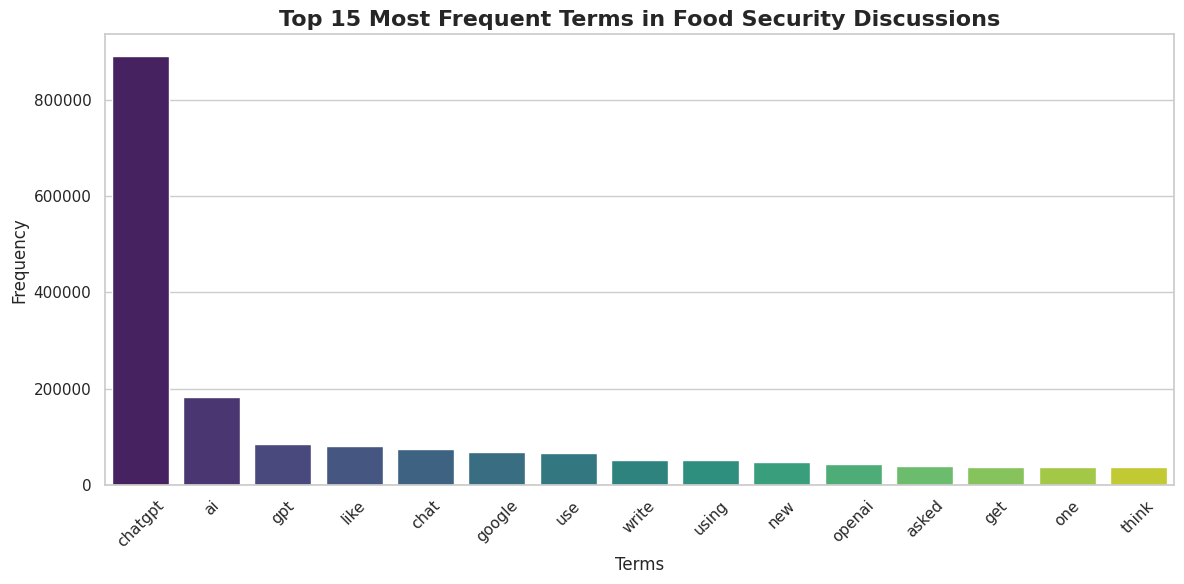

In [ ]:
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Build DataFrame for seaborn compatibility
words_df = pd.DataFrame({'term': words_to_plot, 'frequency': counts_to_plot})

sns.barplot(
    data=words_df,
    x='term',
    y='frequency',
    palette="viridis"
)

plt.title(
    'Top 15 Most Frequent Terms in Food Security Discussions',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Terms', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


### Explore Metadata

In [ ]:
print("Available Columns:")
print(df.columns.tolist())

print("-" * 50)

required_columns = [
    'likes',
    'retweets',
    'replies',
    'followers',
    'predicted_label',
    'location'
]

missing = [col for col in required_columns if col not in df.columns]

if missing:
    print("Missing columns:", missing)

# Dataset dimensions
print(f"Number of Rows: {df.shape[0]:,}")
print(f"Number of Columns: {df.shape[1]}")

if 'location' in df.columns:
    top_locations = (
        df['location']
        .replace('', pd.NA)
        .dropna()
        .value_counts()
        .head(5)
    )
    print("\nTop 5 Locations:")
    print(top_locations)
else:
    print("\n'location' column not found in dataset.")


Available Columns:
['Text', 'negative', 'neutral', 'positive', 'predicted_label', 'date', 'likes', 'location', 'followers', 'following', 'retweets', 'replies', 'cleaned_words', 'cleaned_text']
--------------------------------------------------
Number of Rows: 975,027
Number of Columns: 14

Top 5 Locations:
location
United States        11208
India                10201
London, England       7527
San Francisco, CA     7001
New York, NY          6713
Name: count, dtype: int64


### Engagement Statistics

In [ ]:
print("\nAverage Engagement Metrics:")

print(f"Average Likes: {df['likes'].mean():.2f}")
print(f"Average Retweets: {df['retweets'].mean():.2f}")
print(f"Average Replies: {df['replies'].mean():.2f}")
print(f"Average Followers: {df['followers'].mean():.2f}")


Average Engagement Metrics:
Average Likes: 11.97
Average Retweets: 1.77
Average Replies: 1.11
Average Followers: 32328.90


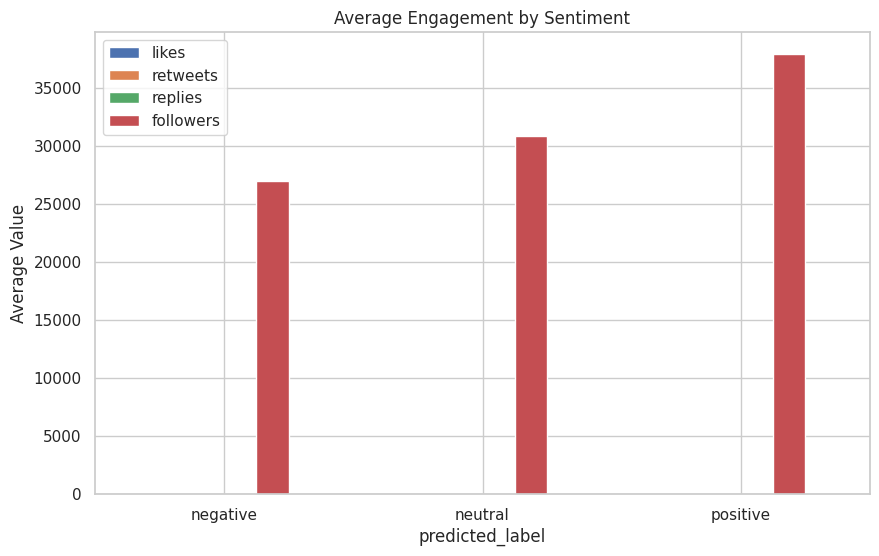

In [ ]:
engagement_by_sentiment.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Average Engagement by Sentiment')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.show()

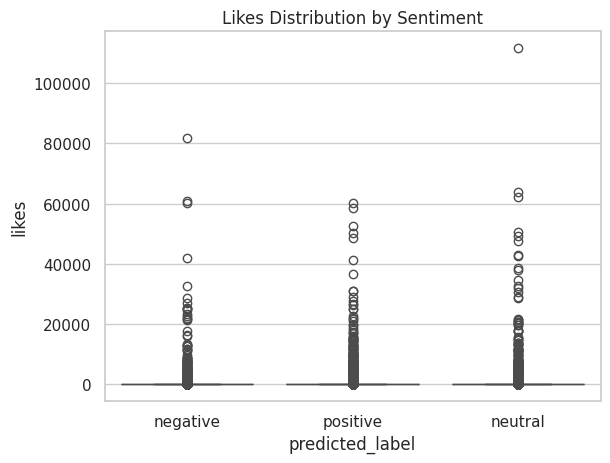

In [ ]:
sns.boxplot(
    x='predicted_label',
    y='likes',
    data=df
)

plt.title('Likes Distribution by Sentiment')
plt.show()

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    engagement_by_sentiment,
    annot=True,
    cmap='YlGnBu',
    fmt='.1f'
)

plt.title("Engagement Heatmap by Sentiment")
plt.show()

### Sentiment Distribution

In [ ]:
print("\nSentiment Distribution:")
sentiment_counts = df['predicted_label'].value_counts()

print(sentiment_counts)

# Percentage breakdown
print("\nSentiment Percentage:")

sentiment_percentage = (
    df['predicted_label']
    .value_counts(normalize=True)
    * 100
).round(2)

print(sentiment_percentage)


Sentiment Distribution:
predicted_label
neutral     442168
positive    323976
negative    208883
Name: count, dtype: int64

Sentiment Percentage:
predicted_label
neutral     45.35
positive    33.23
negative    21.42
Name: proportion, dtype: float64


### Visualizing Sentiment Distribution

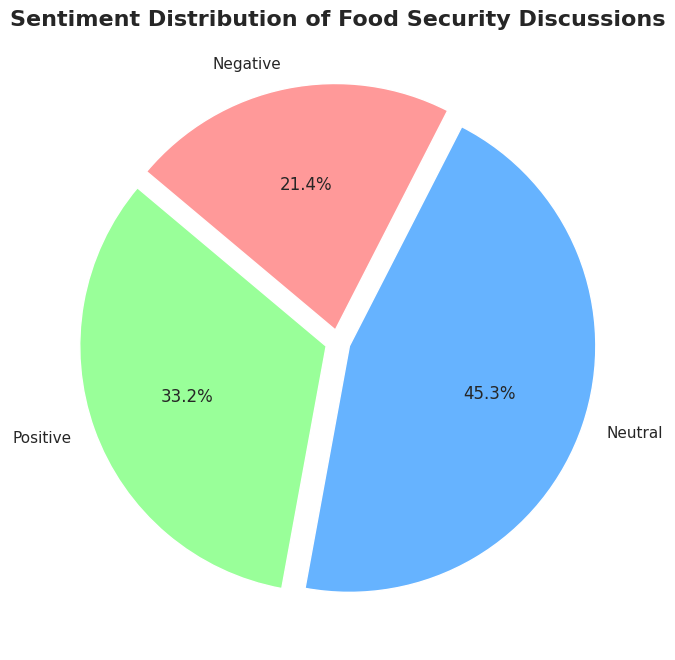


Exact Count per Category:
predicted_label
positive    323976
neutral     442168
negative    208883
Name: count, dtype: int64


In [ ]:
# Arrange sentiments in fixed order
sentiment_counts = (
    df['predicted_label']
    .value_counts()
    .reindex(['positive', 'neutral', 'negative'],fill_value=0)
)

plt.figure(figsize=(8, 8))

plt.pie(
    sentiment_counts,
    labels=['Positive', 'Neutral', 'Negative'],
    autopct='%1.1f%%',
    startangle=140,
    colors=['#99ff99', '#66b3ff', '#ff9999'],
    explode=(0.05, 0.05, 0.05)
)

plt.title(
    'Sentiment Distribution of Food Security Discussions',
    fontsize=16,
    fontweight='bold'
)

plt.show()

print("\nExact Count per Category:")
print(sentiment_counts)

### WordCloud by Sentiment Class

In [ ]:
from wordcloud import WordCloud

for sentiment in ['positive', 'neutral', 'negative']:

    text_col = 'model_text' if 'model_text' in df.columns else 'cleaned_text'
    text = " ".join(
        df[df['predicted_label'] == sentiment][text_col].astype(str)
    )

    wc = WordCloud(
        width=1000,
        height=500,
        background_color='white'
    ).generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wc)
    plt.axis('off')
    plt.title(f'{sentiment.capitalize()} Word Cloud')
    plt.show()

### Sample Records

In [ ]:
df[['Text',
    'predicted_label',
    'likes',
    'retweets',
    'replies',
    'followers',
    'location']].head(10)

,Text,predicted_label,likes,retweets,replies,followers,location
0,If I were a journalist or reporter writing cli...,negative,1,0,0,2012,Fukuoka 福岡 | Japan 日本
1,Imagine if the mid season twist was that theyr...,positive,8,1,2,19855,"Manhattan, NY"
2,I see the difference between leader and employ...,positive,4,0,1,23,NaN
3,Which means your job is at risk Bill Gates say...,neutral,0,0,0,108,NaN
4,What have you been using Chatgpt for?,neutral,1,0,1,11155,"Chicago, IL"
5,ChatGPT is sick of me.,negative,1,1,0,136,"Dubai, United Arab Emirates"
6,I should ask ChatGPT to expound upon each of m...,neutral,0,0,0,967,bk ny
7,just put my dad on to chatgpt and hes already ...,positive,0,0,0,18,NaN
8,ChatGPT is great with ideas But it's horrible ...,negative,4,0,0,2797,Amiens 🇫🇷
9,Perhaps you can put that billion of investment...,neutral,1,0,0,10,NaN


## Preprocessing for Model Training
This cell we done lowercase, remove URLs, remove mentions and hashtag symbols, remove numbers and punctuation, remove extra spaces, tokenize, remove stopwords, remove short tokens, and lemmatize

In [ ]:
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def preprocess_for_model(text):
    # Lowercase
    text = str(text).lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove mentions and hashtag symbols
    text = re.sub(r'@\w+|#', '', text)
    # Remove numbers and punctuation
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    # Tokenize
    words = text.split()
    # Remove stopwords (keep negations for sentiment)
    negations = {'not', 'no', 'never', 'nor', 'neither'}
    filtered = [w for w in words if w not in stop_words or w in negations]
    # Remove short tokens
    filtered = [w for w in filtered if len(w) > 2]
    # Lemmatize
    lemmatized = [lemmatizer.lemmatize(w) for w in filtered]
    return ' '.join(lemmatized)

df['model_text'] = df['Text'].apply(preprocess_for_model)
print('Preprocessing done.')
print(df[['Text', 'model_text']].head(3))


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Preprocessing done.
                                                Text  \
0  If I were a journalist or reporter writing cli...   
1  Imagine if the mid season twist was that theyr...   
2  I see the difference between leader and employ...   

                                          model_text  
0  journalist reporter writing click bait living ...  
1  imagine mid season twist theyre dating chatgpt...  
2  see difference leader employee mentality googl...  


## Label Encoding & Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['predicted_label'])
print('Label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

X = df['model_text']
y = df['label_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {len(X_train):,} | Test size: {len(X_test):,}')


Label mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}
Train size: 780,021 | Test size: 195,006


## Machine Learning Models

### TF-IDF Vectorization

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'TF-IDF matrix shape: {X_train_tfidf.shape}')


TF-IDF matrix shape: (780021, 10000)


### Naive Bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_pred = nb_model.predict(X_test_tfidf)

nb_acc = accuracy_score(y_test, nb_pred)
print(f'Naive Bayes Accuracy: {nb_acc:.4f}')
print(classification_report(y_test, nb_pred, target_names=le.classes_))


Naive Bayes Accuracy: 0.6918
              precision    recall  f1-score   support

    negative       0.69      0.50      0.58     41777
     neutral       0.67      0.82      0.74     88434
    positive       0.73      0.65      0.68     64795

    accuracy                           0.69    195006
   macro avg       0.70      0.65      0.67    195006
weighted avg       0.69      0.69      0.69    195006



### Support Vector Machine (SVM)

In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(max_iter=2000, random_state=42)
svm_model.fit(X_train_tfidf, y_train)
svm_pred = svm_model.predict(X_test_tfidf)

svm_acc = accuracy_score(y_test, svm_pred)
print(f'SVM Accuracy: {svm_acc:.4f}')
print(classification_report(y_test, svm_pred, target_names=le.classes_))


SVM Accuracy: 0.7376
              precision    recall  f1-score   support

    negative       0.72      0.60      0.65     41777
     neutral       0.73      0.82      0.77     88434
    positive       0.76      0.72      0.74     64795

    accuracy                           0.74    195006
   macro avg       0.74      0.71      0.72    195006
weighted avg       0.74      0.74      0.74    195006



### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=30,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_tfidf, y_train)
rf_pred = rf_model.predict(X_test_tfidf)

rf_acc = accuracy_score(y_test, rf_pred)
print(f'Random Forest Accuracy: {rf_acc:.4f}')
print(classification_report(y_test, rf_pred, target_names=le.classes_))

Random Forest Accuracy: 0.5768
              precision    recall  f1-score   support

    negative       0.86      0.05      0.10     41777
     neutral       0.53      0.95      0.68     88434
    positive       0.76      0.41      0.53     64795

    accuracy                           0.58    195006
   macro avg       0.72      0.47      0.44    195006
weighted avg       0.68      0.58      0.51    195006



## Deep Learning Models

### Tokenization & Padding

> **Note on features:** ML models (Naive Bayes, SVM, Random Forest) use **TF-IDF** vectors. DL models (ANN, CNN, LSTM, RNN) use **learned Embedding + sequence** representations. This is part of the comparison — feature engineering vs end-to-end learned features.

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

MAX_WORDS  = 30000
MAX_LEN    = 150
NUM_CLASSES = len(le.classes_)

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN, padding='post')
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test),  maxlen=MAX_LEN, padding='post')

y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  NUM_CLASSES)

print(f'Train sequences shape: {X_train_seq.shape}')
print(f'Test  sequences shape: {X_test_seq.shape}')

Train sequences shape: (780021, 150)
Test  sequences shape: (195006, 150)


## Define Class Weights

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Class weights to handle imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print("Class Weights:")
print(class_weights)

Class Weights:
{0: np.float64(1.5559405407346236), 1: np.float64(0.7350353655571701), 2: np.float64(1.003186962007246)}


### CNN (Convolutional Neural Network)

#### ResNet

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, GlobalMaxPooling1D,
    Dense, BatchNormalization, Dropout, Add, Activation
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import numpy as np

# 1. Early Stopping Optimized for Slow Learning
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,                 # Keeps it efficient, stops when overfitting holds for 4 epochs
    restore_best_weights=True
)

# --- RESNET FUNCTIONAL ARCHITECTURE ---
inputs = Input(shape=(MAX_LEN,))

# Embedding Layer
x = Embedding(MAX_WORDS, 64, input_length=MAX_LEN)(inputs)

# First Conv Block to set up the feature dimensions
x = Conv1D(64, 5, padding='same')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)

# --- RESIDUAL BLOCK 1 ---
# Save the shortcut identity
shortcut = x

# Convolutional path
x = Conv1D(64, 5, padding='same')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)

x = Conv1D(64, 5, padding='same')(x)
x = BatchNormalization()(x)

# The ResNet Magic: Add the shortcut back before the final activation
x = Add()([x, shortcut])
x = Activation('relu')(x)
# ------------------------

# Pooling down to a 1D Vector
x = GlobalMaxPooling1D()(x)

# Regularized Classifier Dense Block
x = Dense(64)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x) # Keeps the training & validation lines close together

outputs = Dense(NUM_CLASSES, activation='softmax')(x)

# Construct the Model
resnet_model = Model(inputs=inputs, outputs=outputs)
# --------------------------------------

# 2. Slow Down Learning Rate for Smooth Convergence over 10+ Epochs
slow_adam = Adam(learning_rate=0.0001)

resnet_model.compile(optimizer=slow_adam, loss='categorical_crossentropy', metrics=['accuracy'])
resnet_model.summary()

# 3. Adjusted Batch Size and Validation Split for massive data
BATCH_SIZE = 128

resnet_history = resnet_model.fit(
    X_train_seq, y_train_cat,
    epochs=15,                  # Reduced from 100 for faster demonstration
    batch_size=BATCH_SIZE,
    validation_split=0.2,        # Increased to 20% for stable curve tracking
    callbacks=[early_stop],
    verbose=1,
    class_weight=class_weights
)

# 4. Evaluation
resnet_loss, resnet_acc = resnet_model.evaluate(X_test_seq, y_test_cat, verbose=0)
print(f'\nResNet Test Accuracy: {resnet_acc:.4f}')

resnet_pred = np.argmax(resnet_model.predict(X_test_seq), axis=1)
print(classification_report(y_test, resnet_pred, target_names=le.classes_))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 150)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 150, 64)   │  1,920,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 150, 64)   │     20,544 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 150, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 150, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 150, 64)   │     20,544 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 64)   │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 150, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 150, 64)   │     20,544 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 64)   │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 150, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 150, 64)   │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ activation_2[0][… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64)        │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │        195 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,987,011 (7.58 MB)

 Trainable params: 1,986,499 (7.58 MB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/15
4876/4876 ━━━━━━━━━━━━━━━━━━━━ 58s 9ms/step - accuracy: 0.5665 - loss: 0.9202 - val_accuracy: 0.7111 - val_loss: 0.6746
Epoch 2/15
4876/4876 ━━━━━━━━━━━━━━━━━━━━ 40s 8ms/step - accuracy: 0.7284 - loss: 0.6332 - val_accuracy: 0.7356 - val_loss: 0.6180
Epoch 3/15
4876/4876 ━━━━━━━━━━━━━━━━━━━━ 40s 8ms/step - accuracy: 0.7592 - loss: 0.5670 - val_accuracy: 0.7423 - val_loss: 0.6068
Epoch 4/15
4876/4876 ━━━━━━━━━━━━━━━━━━━━ 40s 8ms/step - accuracy: 0.7841 - loss: 0.5142 - val_accuracy: 0.7520 - val_loss: 0.5989
Epoch 5/15
4876/4876 ━━━━━━━━━━━━━━━━━━━━ 40s 8ms/step - accuracy: 0.8083 - loss: 0.4616 - val_accuracy: 0.7432 - val_loss: 0.6315
Epoch 6/15
4876/4876 ━━━━━━━━━━━━━━━━━━━━ 40s 8ms/step - accuracy: 0.8310 - loss: 0.4122 - val_accuracy: 0.7392 - val_loss: 0.6700
Epoch 7/15
4876/4876 ━━━━━━━━━━━━━━━━━━━━ 41s 8ms/step - accuracy: 0.8514 - loss: 0.3663 - val_accuracy: 0.7413 - val_loss: 0.7150
Epoch 8/15
4876/4876 ━━━━━━━━━━━━━━━━━━━━ 41s 8ms/step - accuracy: 0.8686 - loss: 0

#### ReLu

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Conv1D, GlobalMaxPooling1D,
    Dense, BatchNormalization, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

cnn_model = Sequential([
    Embedding(MAX_WORDS, 64, input_length=MAX_LEN),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn_model.summary()

cnn_history = cnn_model.fit(
    X_train_seq, y_train_cat,
    epochs=5, batch_size=64, # Reduced from 15 for faster demonstration
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1,
    class_weight=class_weights
)

cnn_loss, cnn_acc = cnn_model.evaluate(X_test_seq, y_test_cat, verbose=0)
print(f'\nCNN Test Accuracy: {cnn_acc:.4f}')
cnn_pred = np.argmax(cnn_model.predict(X_test_seq), axis=1)
print(classification_report(y_test, cnn_pred, target_names=le.classes_))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
10970/10970 ━━━━━━━━━━━━━━━━━━━━ 62s 5ms/step - accuracy: 0.7027 - loss: 0.6878 - val_accuracy: 0.7409 - val_loss: 0.6061
Epoch 2/5
10970/10970 ━━━━━━━━━━━━━━━━━━━━ 52s 5ms/step - accuracy: 0.7575 - loss: 0.5797 - val_accuracy: 0.7452 - val_loss: 0.6018
Epoch 3/5
10970/10970 ━━━━━━━━━━━━━━━━━━━━ 53s 5ms/step - accuracy: 0.7897 - loss: 0.5110 - val_accuracy: 0.7415 - val_loss: 0.6148
Epoch 4/5
10970/10970 ━━━━━━━━━━━━━━━━━━━━ 52s 5ms/step - accuracy: 0.8174 - loss: 0.4510 - val_accuracy: 0.7538 - val_loss: 0.6192
Epoch 5/5
10970/10970 ━━━━━━━━━━━━━━━━━━━━ 51s 5ms/step - accuracy: 0.8404 - loss: 0.3999 - val_accuracy: 0.7410 - val_loss: 0.7003

CNN Test Accuracy: 0.7467
6094/6094 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step
              precision    recall  f1-score   support

    negative       0.68      0.76      0.71     41777
     neutral       0.83      0.68      0.75     88434
    positive       0.71      0.84      0.77     64795

    accuracy                           0.75    1950

## ANN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, Embedding,
    GlobalAveragePooling1D,
    BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report
import numpy as np

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

ann_model = Sequential([
    Embedding(MAX_WORDS, 64, input_length=MAX_LEN),

    GlobalAveragePooling1D(),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(NUM_CLASSES, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

ann_history = ann_model.fit(
    X_train_seq,
    y_train_cat,
    epochs=5, # Reduced from 15 for faster demonstration
    batch_size=128,
    validation_split=0.1,
    class_weight=class_weights,   # <-- added
    callbacks=[early_stop],
    verbose=1
)

ann_loss, ann_acc = ann_model.evaluate(
    X_test_seq,
    y_test_cat,
    verbose=0
)

print(f'\nANN Test Accuracy: {ann_acc:.4f}')

ann_pred = np.argmax(
    ann_model.predict(X_test_seq),
    axis=1
)

print(
    classification_report(
        y_test,
        ann_pred,
        target_names=le.classes_,
        zero_division=0
    )
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 33s 5ms/step - accuracy: 0.6889 - loss: 0.7171 - val_accuracy: 0.7159 - val_loss: 0.6658
Epoch 2/5
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step - accuracy: 0.7273 - loss: 0.6352 - val_accuracy: 0.7071 - val_loss: 0.7040
Epoch 3/5
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step - accuracy: 0.7356 - loss: 0.6140 - val_accuracy: 0.7291 - val_loss: 0.6888
Epoch 4/5
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step - accuracy: 0.7400 - loss: 0.6013 - val_accuracy: 0.5643 - val_loss: 0.9526

ANN Test Accuracy: 0.7162
6094/6094 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step
              precision    recall  f1-score   support

    negative       0.67      0.67      0.67     41777
     neutral       0.80      0.65      0.72     88434
    positive       0.66      0.83      0.74     64795

    accuracy                           0.72    195006
   macro avg       0.71      0.72      0.71    195006
weighted avg       0.73      0.72      0.72    195006



### LSTM (Long Short-Term Memory)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report
import numpy as np

MAX_WORDS = 30000
MAX_LEN = 150

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

lstm_model = Sequential([
    Embedding(input_dim=MAX_WORDS,
              output_dim=128,
              input_length=MAX_LEN),

    Bidirectional(
    LSTM(
        64,
        return_sequences=True,
        dropout=0.3
    )
),

Bidirectional(
    LSTM(
        32,
        dropout=0.3
    )
),

Dense(64, activation='relu'),
Dropout(0.5),

    Dense(NUM_CLASSES, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

lstm_history = lstm_model.fit(
    X_train_seq,
    y_train,
    epochs=5, # Reduced from 15 for faster demonstration
    batch_size=128,
    validation_split=0.1,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

lstm_loss, lstm_acc = lstm_model.evaluate(
    X_test_seq,
    y_test,
    verbose=0
)

print(f"\nLSTM Test Accuracy: {lstm_acc:.4f}")

lstm_pred = np.argmax(
    lstm_model.predict(X_test_seq),
    axis=1
)

print(
    classification_report(
        y_test,
        lstm_pred,
        target_names=le.classes_,
        zero_division=0
    )
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 206s 36ms/step - accuracy: 0.7139 - loss: 0.6621 - val_accuracy: 0.7487 - val_loss: 0.6040
Epoch 2/5
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 196s 36ms/step - accuracy: 0.7587 - loss: 0.5665 - val_accuracy: 0.7532 - val_loss: 0.5877
Epoch 3/5
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 200s 35ms/step - accuracy: 0.7765 - loss: 0.5295 - val_accuracy: 0.7571 - val_loss: 0.5786
Epoch 4/5
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 197s 36ms/step - accuracy: 0.7898 - loss: 0.4991 - val_accuracy: 0.7532 - val_loss: 0.6014
Epoch 5/5
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 199s 35ms/step - accuracy: 0.8023 - loss: 0.4727 - val_accuracy: 0.7541 - val_loss: 0.6113

LSTM Test Accuracy: 0.7588
6094/6094 ━━━━━━━━━━━━━━━━━━━━ 65s 11ms/step
              precision    recall  f1-score   support

    negative       0.66      0.79      0.72     41777
     neutral       0.82      0.72      0.77     88434
    positive       0.77      0.78      0.78     64795

    accuracy                           0.76    19

### RNN (Recurrent Neural Network)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report
import numpy as np

rnn_model = Sequential([
    Embedding(input_dim=MAX_WORDS,
              output_dim=128,
              input_length=MAX_LEN),

    Bidirectional(
        SimpleRNN(
            128,
            return_sequences=True
        )
    ),

    Bidirectional(
        SimpleRNN(
            64
        )
    ),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(NUM_CLASSES, activation='softmax')
])

rnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

rnn_model.summary()

rnn_history = rnn_model.fit(
    X_train_seq,
    y_train,
    epochs=5, # Reduced from 15 for faster demonstration
    batch_size=128,
    validation_split=0.1,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

rnn_loss, rnn_acc = rnn_model.evaluate(
    X_test_seq,
    y_test,
    verbose=0
)

print(f"\nRNN Test Accuracy: {rnn_acc:.4f}")

rnn_pred = np.argmax(
    rnn_model.predict(X_test_seq),
    axis=1
)

print(
    classification_report(
        y_test,
        rnn_pred,
        target_names=le.classes_,
        zero_division=0
    )
)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 313s 55ms/step - accuracy: 0.6851 - loss: 0.7208 - val_accuracy: 0.7173 - val_loss: 0.6592
Epoch 2/5
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 310s 54ms/step - accuracy: 0.7359 - loss: 0.6217 - val_accuracy: 0.7156 - val_loss: 0.6585
Epoch 3/5
5485/5485 ━━━━━━━━━━━━━━━━━━━━ 294s 54ms/step - accuracy: 0.7398 - loss: 0.6082 - val_accuracy: 0.7138 - val_loss: 0.6788

RNN Test Accuracy: 0.7177
6094/6094 ━━━━━━━━━━━━━━━━━━━━ 74s 12ms/step
              precision    recall  f1-score   support

    negative       0.62      0.75      0.68     41777
     neutral       0.82      0.64      0.72     88434
    positive       0.70      0.81      0.75     64795

    accuracy                           0.72    195006
   macro avg       0.71      0.73      0.71    195006
weighted avg       0.73      0.72      0.72    195006



## Comparative Analysis

### Performance Metrics — All Models

In [ ]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

results = {
    'Model':              ['Naive Bayes', 'SVM', 'Random Forest', 'ANN', 'ResNet', 'CNN', 'LSTM', 'RNN'],
    'Type':               ['ML', 'ML', 'ML', 'DL', 'DL', 'DL', 'DL', 'DL'],
    'Feature':            ['TF-IDF', 'TF-IDF', 'TF-IDF', 'Embedding', 'Embedding', 'Embedding', 'Embedding', 'Embedding'],
    'Accuracy':  [
        nb_acc, svm_acc, rf_acc,
        ann_acc, resnet_acc, cnn_acc, lstm_acc, rnn_acc
    ],
    'F1 (macro)': [
        f1_score(y_test, nb_pred,   average='macro'),
        f1_score(y_test, svm_pred,  average='macro'),
        f1_score(y_test, rf_pred,   average='macro'),
        f1_score(y_test, ann_pred,  average='macro'),
        f1_score(y_test, resnet_pred,  average='macro'),
        f1_score(y_test, cnn_pred,  average='macro'),
        f1_score(y_test, lstm_pred, average='macro'),
        f1_score(y_test, rnn_pred,  average='macro'),
    ],
    'Precision (macro)': [
        precision_score(y_test, nb_pred,   average='macro'),
        precision_score(y_test, svm_pred,  average='macro'),
        precision_score(y_test, rf_pred,   average='macro'),
        precision_score(y_test, ann_pred,  average='macro'),
        precision_score(y_test, resnet_pred,  average='macro'),
        precision_score(y_test, cnn_pred,  average='macro'),
        precision_score(y_test, lstm_pred, average='macro'),
        precision_score(y_test, rnn_pred,  average='macro'),
    ],
    'Recall (macro)': [
        recall_score(y_test, nb_pred,   average='macro'),
        recall_score(y_test, svm_pred,  average='macro'),
        recall_score(y_test, rf_pred,   average='macro'),
        recall_score(y_test, ann_pred,  average='macro'),
        recall_score(y_test, resnet_pred,  average='macro'),
        recall_score(y_test, cnn_pred,  average='macro'),
        recall_score(y_test, lstm_pred, average='macro'),
        recall_score(y_test, rnn_pred,  average='macro'),
    ],
}

results_df = pd.DataFrame(results).round(4)
results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

        Model Type   Feature  Accuracy  F1 (macro)  Precision (macro)  Recall (macro)
         LSTM   DL Embedding    0.7588      0.7539             0.7471          0.7669
       ResNet   DL Embedding    0.7523      0.7455             0.7406          0.7537
          CNN   DL Embedding    0.7467      0.7426             0.7391          0.7563
          SVM   ML    TF-IDF    0.7376      0.7211             0.7371          0.7112
          RNN   DL Embedding    0.7177      0.7134             0.7097          0.7320
          ANN   DL Embedding    0.7162      0.7097             0.7119          0.7192
  Naive Bayes   ML    TF-IDF    0.6918      0.6674             0.6969          0.6541
Random Forest   ML    TF-IDF    0.5768      0.4367             0.7163          0.4694


### Accuracy Comparison Bar Chart

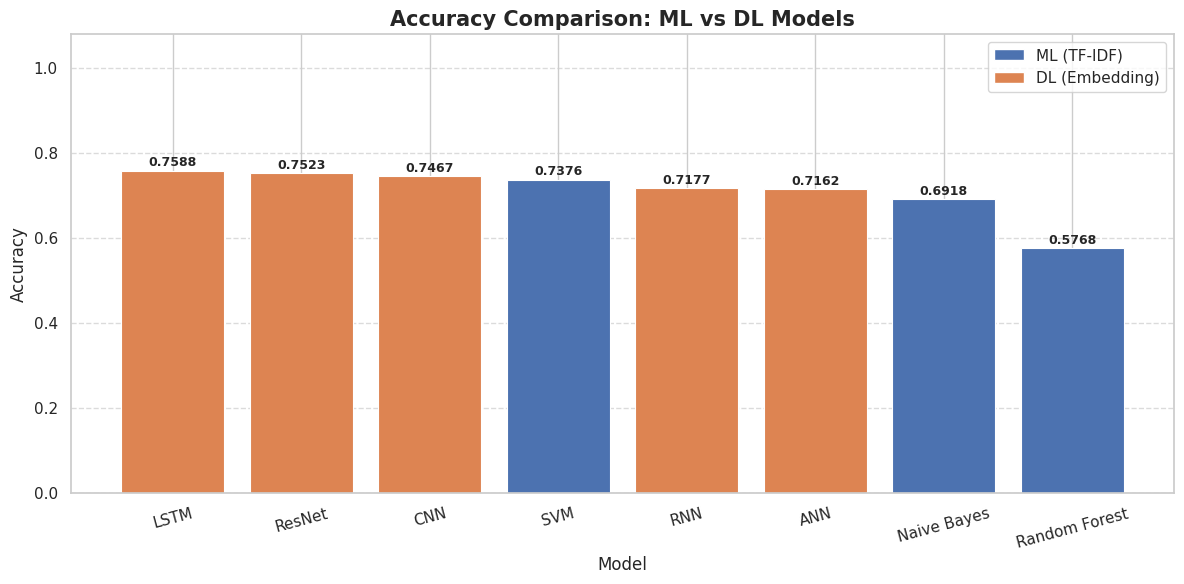

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

palette = {'ML': '#4C72B0', 'DL': '#DD8452'}
colors = [palette[t] for t in results_df['Type']]
bars = ax.bar(results_df['Model'], results_df['Accuracy'],
              color=colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, results_df['Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4C72B0', label='ML (TF-IDF)'),
                   Patch(facecolor='#DD8452', label='DL (Embedding)')]
ax.legend(handles=legend_elements, fontsize=11)

ax.set_title('Accuracy Comparison: ML vs DL Models', fontsize=15, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylim(0, 1.08)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### F1 / Precision / Recall Grouped Chart

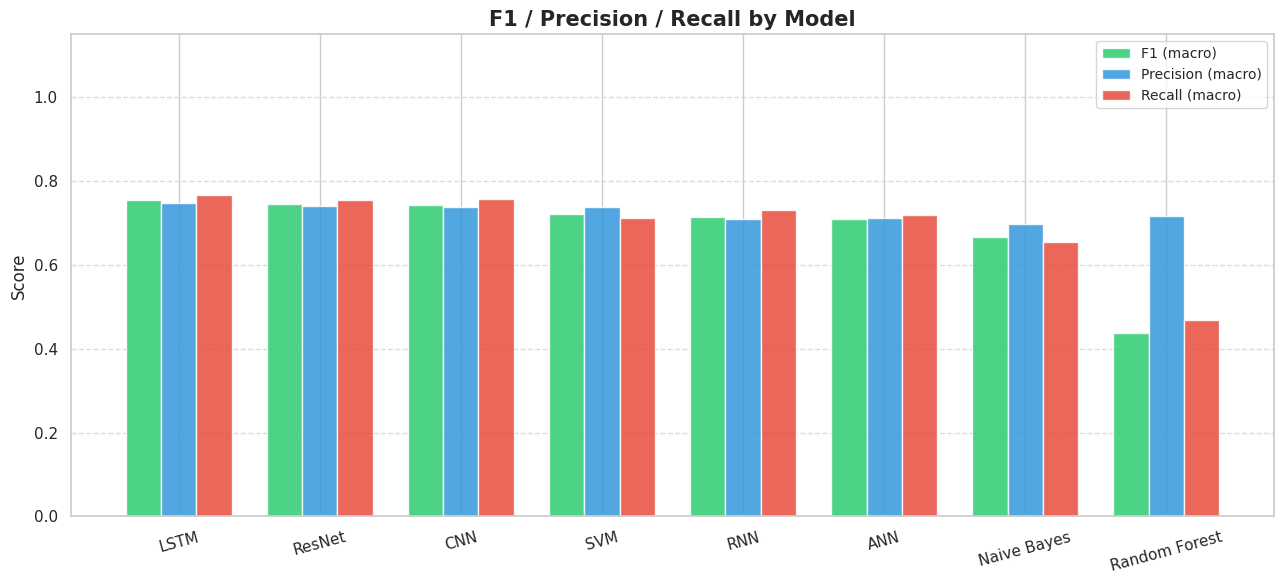

In [ ]:
metrics = ['F1 (macro)', 'Precision (macro)', 'Recall (macro)']
x = np.arange(len(results_df))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
colors_m = ['#2ecc71', '#3498db', '#e74c3c']
for i, (metric, color) in enumerate(zip(metrics, colors_m)):
    ax.bar(x + i * width, results_df[metric], width, label=metric, color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(results_df['Model'], rotation=15)
ax.set_title('F1 / Precision / Recall by Model', fontsize=15, fontweight='bold')
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### ML vs DL — Average Performance

      Accuracy  F1 (macro)  Precision (macro)  Recall (macro)
Type                                                         
DL      0.7383      0.7330             0.7297          0.7456
ML      0.6687      0.6084             0.7168          0.6116


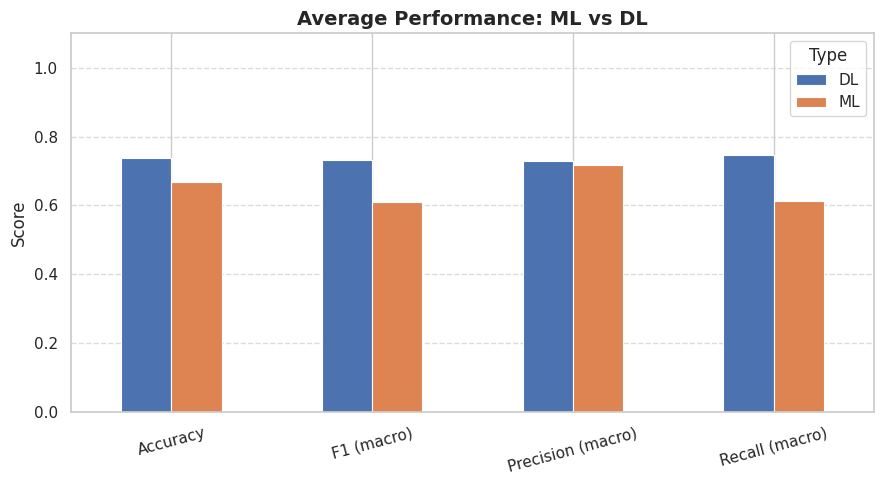

In [ ]:
# Aggregate ML vs DL average metrics
group_summary = results_df.groupby('Type')[['Accuracy', 'F1 (macro)', 'Precision (macro)', 'Recall (macro)']].mean().round(4)
print(group_summary)

group_summary.T.plot(kind='bar', figsize=(9, 5), color=['#4C72B0', '#DD8452'],
                     edgecolor='white', linewidth=0.8)
plt.title('Average Performance: ML vs DL', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0, 1.1)
plt.legend(title='Type')
plt.yaxis.grid(True, linestyle='--', alpha=0.7) if False else plt.gca().yaxis.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Confusion Matrices — All Models

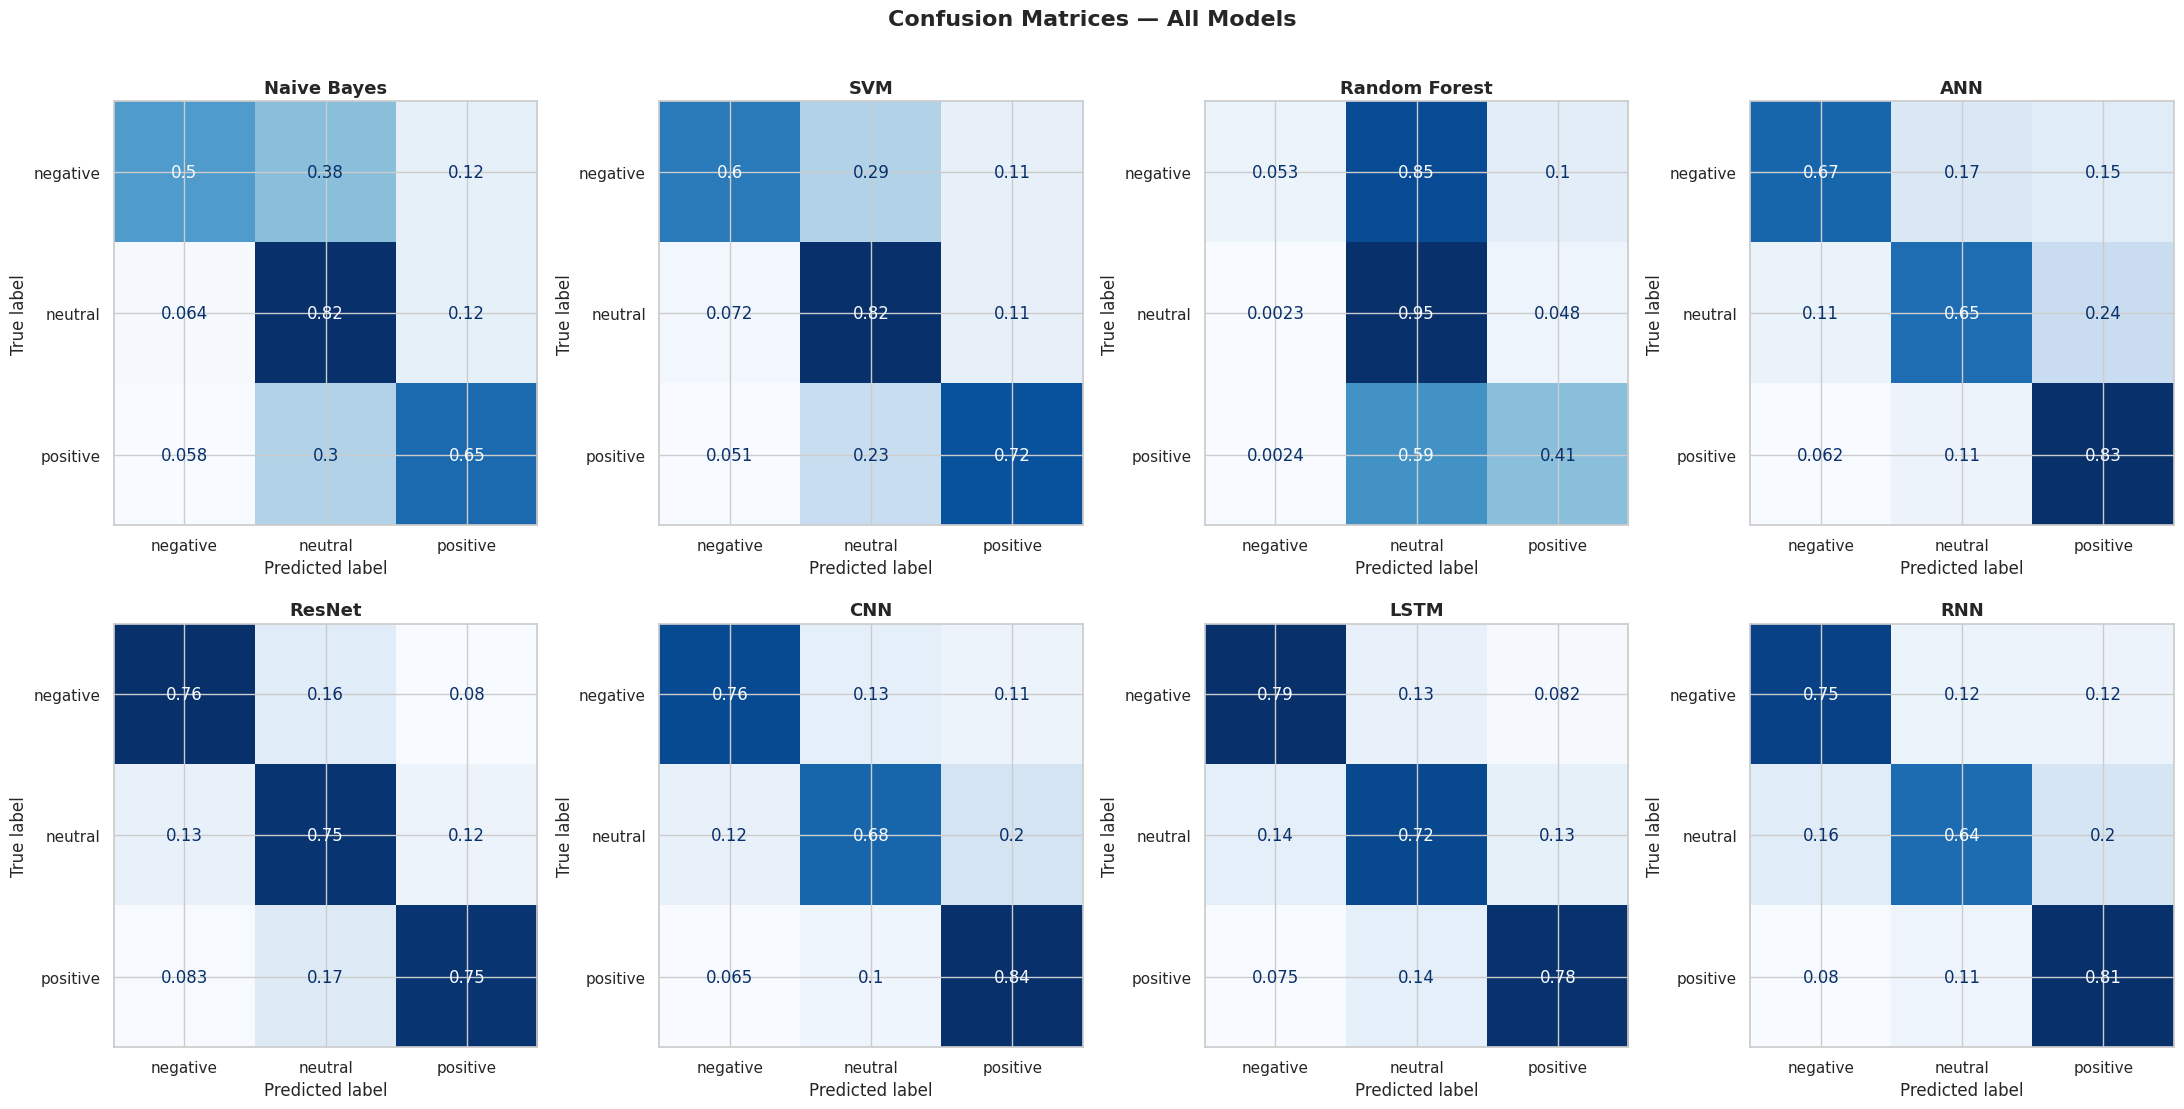

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds  = [nb_pred, svm_pred, rf_pred, ann_pred, resnet_pred, cnn_pred, lstm_pred, rnn_pred]
model_names = ['Naive Bayes', 'SVM', 'Random Forest', 'ANN', 'ResNet', 'CNN', 'LSTM', 'RNN']

fig, axes = plt.subplots(2, 4, figsize=(22, 11))
axes = axes.flatten()

for ax, preds, name in zip(axes, all_preds, model_names):
    cm = confusion_matrix(
    y_test,
    preds,
    normalize='true'
)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=13, fontweight='bold')


plt.suptitle('Confusion Matrices — All Models', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Training History — DL Models

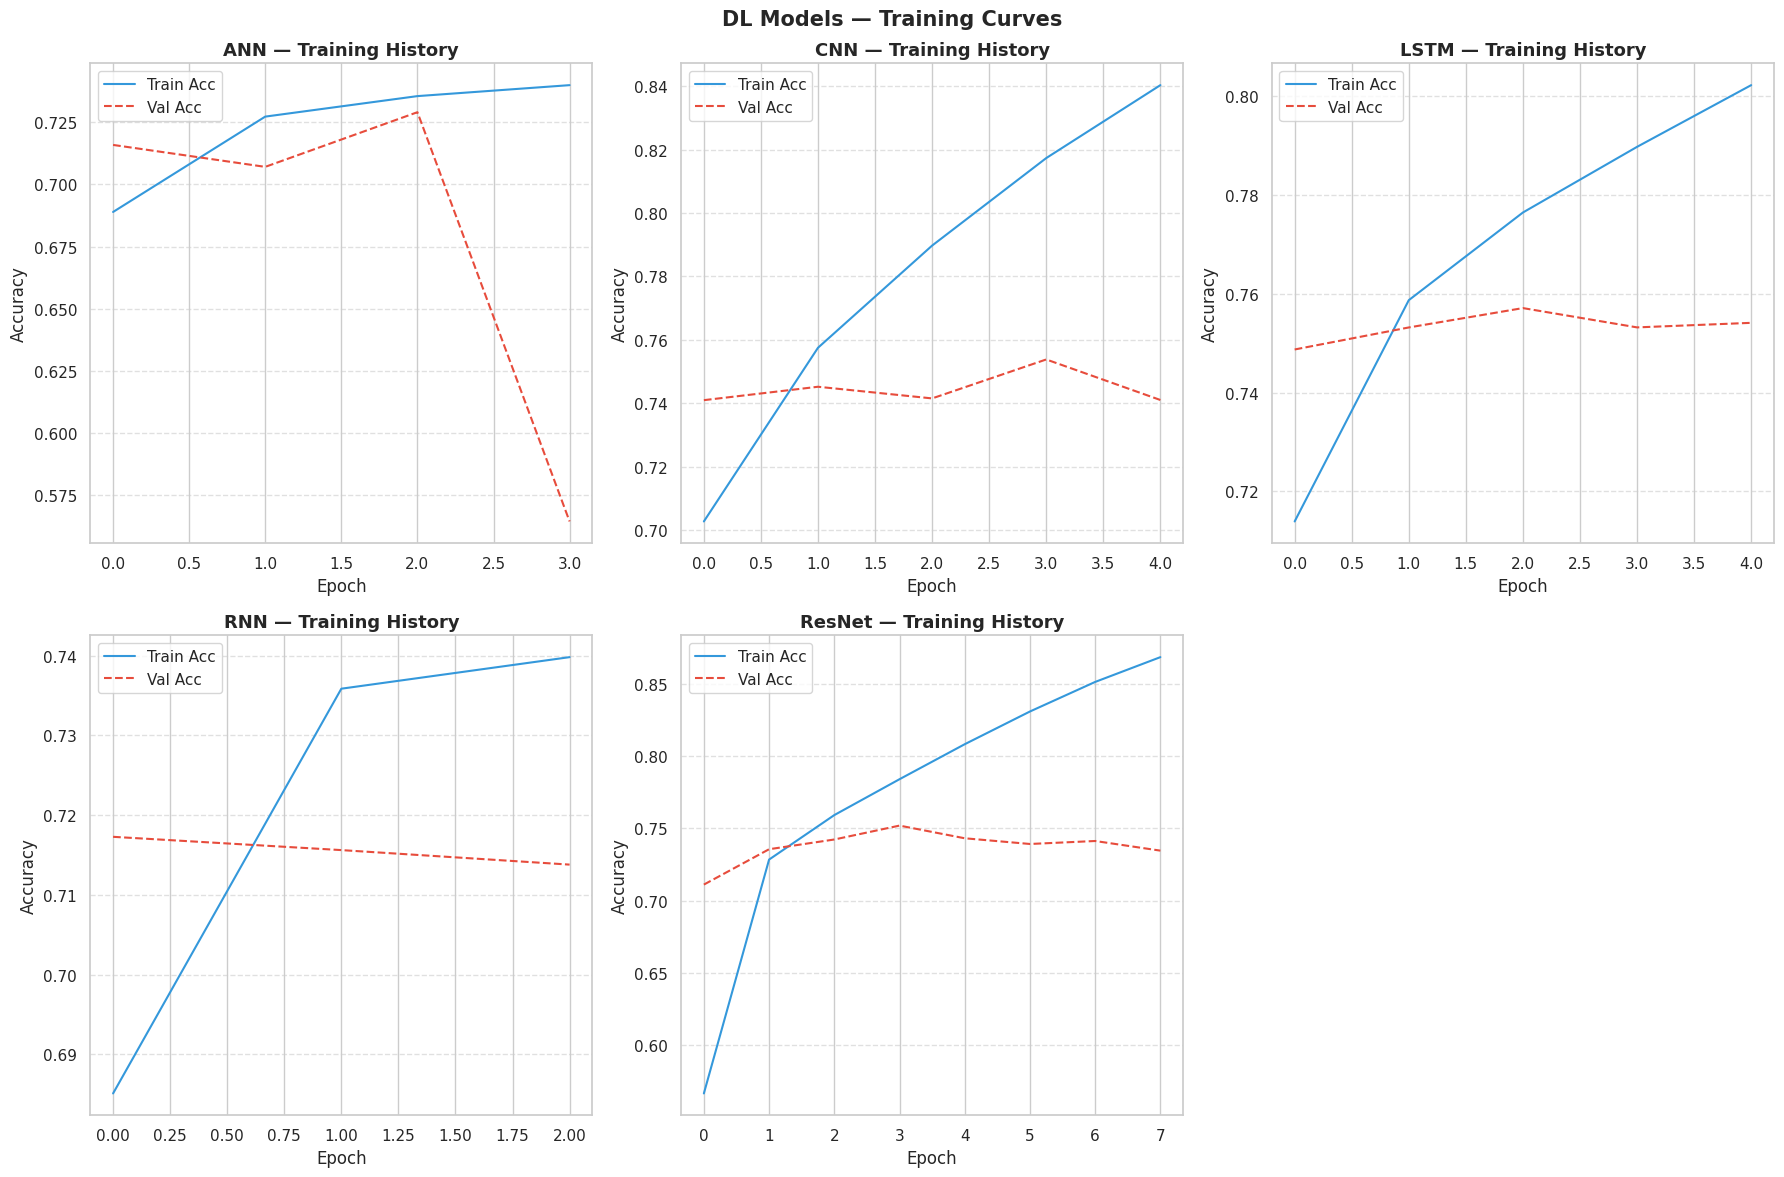

In [ ]:
dl_histories = [
    (ann_history,  'ANN'),
    (cnn_history,  'CNN'),
    (lstm_history, 'LSTM'),
    (rnn_history,  'RNN'),
    (resnet_history, 'ResNet') # Add ResNet history
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12)) # Adjusted for 5 models
axes = axes.flatten()

for i, (history, name) in enumerate(dl_histories):
    ax = axes[i]
    ax.plot(history.history['accuracy'],     label='Train Acc', color='#3498db')
    ax.plot(history.history['val_accuracy'], label='Val Acc',   color='#e74c3c', linestyle='--')
    ax.set_title(f'{name} — Training History', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.yaxis.grid(True, linestyle='--', alpha=0.6)

# Hide the extra subplot if there are an odd number of models for a 2xN grid
if len(dl_histories) < len(axes):
    for j in range(len(dl_histories), len(axes)):
        axes[j].set_visible(False)

plt.suptitle('DL Models — Training Curves', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Ensure results_df is available from previous cells (cell cwdrDSSCHJ_-)
# If this cell is run independently, you might need to re-run preceding cells
# to define results_df.

benchmark_table = results_df[['Model', 'Type', 'F1 (macro)', 'Precision (macro)', 'Recall (macro)']]

print("Precision, Recall, and F1 Benchmark for All Models:")
print("=" * 70)
print(benchmark_table.to_string(index=False))
print("=" * 70)

### Summary Table & Best Model

In [ ]:
print('=' * 75)
print('              FINAL MODEL COMPARISON SUMMARY')
print('=' * 75)
print(results_df[['Model', 'Type', 'Feature', 'Accuracy', 'F1 (macro)']].to_string(index=False))
print('=' * 75)

best = results_df.iloc[0]
worst = results_df.iloc[-1]

print(f"\n Best Model  : {best['Model']} ({best['Type']}, {best['Feature']})")
print(f" Accuracy    : {best['Accuracy']:.4f}")
print(f" F1 (macro)  : {best['F1 (macro)']:.4f}")
print(f"\n Worst Model : {worst['Model']} ({worst['Type']}, {worst['Feature']})")
print(f" Accuracy    : {worst['Accuracy']:.4f}")
print(f" F1 (macro)  : {worst['F1 (macro)']:.4f}")

ml_avg = results_df[results_df['Type']=='ML']['Accuracy'].mean()
dl_avg = results_df[results_df['Type']=='DL']['Accuracy'].mean()
winner = 'DL (Embedding-based)' if dl_avg > ml_avg else 'ML (TF-IDF-based)'
print(f"\n Overall winner  : {winner}")
print(f" Avg ML Accuracy : {ml_avg:.4f}")
print(f" Avg DL Accuracy : {dl_avg:.4f}")


              FINAL MODEL COMPARISON SUMMARY


NameError: name 'results_df' is not defined

## Saving All Models

In [ ]:
import joblib
import os

# Define the directory path
models_dir = '/content/drive/My Drive/models/'

# Create the directory if it doesn't exist
os.makedirs(models_dir, exist_ok=True)

# Save ML models
joblib.dump(nb_model, os.path.join(models_dir, 'naive_bayes_model.joblib'))
print("Naive Bayes model saved as 'naive_bayes_model.joblib'")

joblib.dump(svm_model, os.path.join(models_dir, 'svm_model.joblib'))
print("SVM model saved as 'svm_model.joblib'")

joblib.dump(rf_model, os.path.join(models_dir, 'random_forest_model.joblib'))
print("Random Forest model saved as 'random_forest_model.joblib'")

In [ ]:
# Save DL models
ann_model.save(os.path.join(models_dir, 'ann_model.keras'))
print("ANN model saved as 'ann_model.keras'")

cnn_model.save(os.path.join(models_dir, 'cnn_model.keras'))
print("CNN model saved as 'cnn_model.keras'")

lstm_model.save(os.path.join(models_dir, 'lstm_model.keras'))
print("LSTM model saved as 'lstm_model.keras'")

rnn_model.save(os.path.join(models_dir, 'rnn_model.keras'))
print("RNN model saved as 'rnn_model.keras'")

## Make Predictions with the Best Model

Now that we've trained and saved all the models, let's load the best-performing one (LSTM) and use it to make predictions on new, unseen text data.

In [ ]:
from tensorflow.keras.models import load_model
import numpy as np
import os

# Define the directory path where models are saved
models_dir = '/content/drive/My Drive/models/'

# Load the best model (LSTM model)
lstm_model_path = os.path.join(models_dir, 'lstm_model.keras')
best_model = load_model(lstm_model_path)

print(f"Loaded model from: {lstm_model_path}")
best_model.summary()

To make predictions, we need to preprocess the new text data in the same way we preprocessed the training data. This includes cleaning, tokenizing, and padding the sequence.

In [ ]:
# Example of new text to predict
new_texts = [
    "ChatGPT is truly amazing and helps me a lot with my work!",
    "I am so disappointed with the new AI tools, they are not helpful at all.",
    "The latest update to ChatGPT is neither good nor bad, just different."
]

# Preprocess the new text using the same tokenizer and preprocessing function
preprocessed_new_texts = [preprocess_for_model(text) for text in new_texts]

# Convert text to sequences using the trained tokenizer
new_texts_seq = tokenizer.texts_to_sequences(preprocessed_new_texts)

# Pad sequences to the same length as training data
new_texts_padded = pad_sequences(new_texts_seq, maxlen=MAX_LEN, padding='post')

# Make predictions
predictions = best_model.predict(new_texts_padded)

# Get the predicted class (index with highest probability)
predicted_classes = np.argmax(predictions, axis=1)

# Decode numerical labels back to original sentiment labels
predicted_labels = le.inverse_transform(predicted_classes)

print("\nPredictions for new texts:")
for i, text in enumerate(new_texts):
    print(f"Text: '{text}'")
    print(f"Predicted Sentiment: {predicted_labels[i]}\n")